# Visualisations of the Posterior

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

import json

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import feature as cfeature
from matplotlib.patches import Rectangle
from raytracer import SphericalMesh
from scipy import stats
from scipy.interpolate import griddata

import main  # registers all the builder functions used
from config.components import ComponentSpec
from config.models import Config


In [2]:
directory = (
    main.ROOT
    / "outputs"
    / "resolution_gridsearch"
    / "no_bugs"
    / "20260805_161645_64cecbd8"
)
with open(cfg_file := directory / "config_resolved.json") as f:
    cfg_dict = json.load(f)["config"]
    cfg = Config.from_dict(cfg_dict)
mean = np.load(mean_file := directory / "mean.npy")
cov = np.load(cov_file := directory / "cov.npy")
with open(ev_file := directory / "evidence.txt") as f:
    ln_evidence = float(f.read())

print(f"{mean.shape=}")
print(f"{cov.shape=}")
print(f"{ln_evidence=}")

mean.shape=(960,)
cov.shape=(960, 960)
ln_evidence=24979.246705835434


In [3]:
mesh = cfg.mesh.to_mesh()

data_file = main.ROOT / cfg.data.file
df = pd.read_parquet(data_file)
data = (df.delta_t / df.inner_core_travel_time).astype(float).to_numpy()
ic_in = np.stack(df.in_location.tolist())
ic_out = np.stack(df.out_location.tolist())
context = {  # all the arguments to constructors only known at runtime
    "n_params": mesh.n_cells * 3,
    "n_data": data.size,
    "ic_in": ic_in,
    "ic_out": ic_out,
    "ref_phase": df.reference_phase.to_list(),
    "ic_tt": df.inner_core_travel_time.astype(float).to_numpy(),
    "mesh": mesh,
}

In [4]:
def _unpacking_indices(
    n_radial: int, n_lateral: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n_cells = n_radial * n_lateral
    cell_idx = np.arange(n_cells)
    A_idx = 3 * cell_idx
    C_idx = A_idx + 1
    F_idx = A_idx + 2

    return A_idx, C_idx, F_idx


def unpack_mean(
    m: np.ndarray, n_radial: int, n_lateral
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Unpack vector m into A, C, F matrices.

    m is expected to be in a flat radial-major ordering i.e.
        m = [A0, C0, F0, A1, C1, F1,...]
    where the cell index {0, 1,...} is given by
        cell_index = radial_index * n_lateral + lateral_index

    The A, C, F matrices are returned in shape (n_radial, n_lateral).
    """
    A_idx, C_idx, F_idx = _unpacking_indices(n_radial, n_lateral)

    shape = (n_radial, n_lateral)
    return m[A_idx].reshape(*shape), m[C_idx].reshape(*shape), m[F_idx].reshape(*shape)


def unpack_covariance(
    cov: np.ndarray, n_radial: int, n_lateral: int, reshape_blocks: bool = False
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Unpack covariance matrix into AA, AC, AF, CC, CF, FF correlation blocks.

    cov is expected to have shape (n_params, n_params) where each row and comlumn is ordered like in `unpack_mean` i.e. radial-major, lateral_major, param_type

    if reshape_blocks = False
        blocks are returned as (n_cell, n_cell)
    if reshape_blocks = True
        blocks are returned as (n_radial, n_lateral, n_radial, n_lateral).
        Convenient for plotting geographically.
    """
    A_idx, C_idx, F_idx = _unpacking_indices(n_radial, n_lateral)

    AA = cov[np.ix_(A_idx, A_idx)]
    AC = cov[np.ix_(A_idx, C_idx)]
    AF = cov[np.ix_(A_idx, F_idx)]
    CC = cov[np.ix_(C_idx, C_idx)]
    CF = cov[np.ix_(C_idx, F_idx)]
    FF = cov[np.ix_(F_idx, F_idx)]

    if reshape_blocks:

        def rshp(block: np.ndarray) -> np.ndarray:
            return block.reshape(n_radial, n_lateral, n_radial, n_lateral)

        return rshp(AA), rshp(AC), rshp(AF), rshp(CC), rshp(CF), rshp(FF)

    return AA, AC, AF, CC, CF, FF


In [5]:
A, C, F = unpack_mean(mean, mesh.n_radial, mesh.sampling.n_cells)

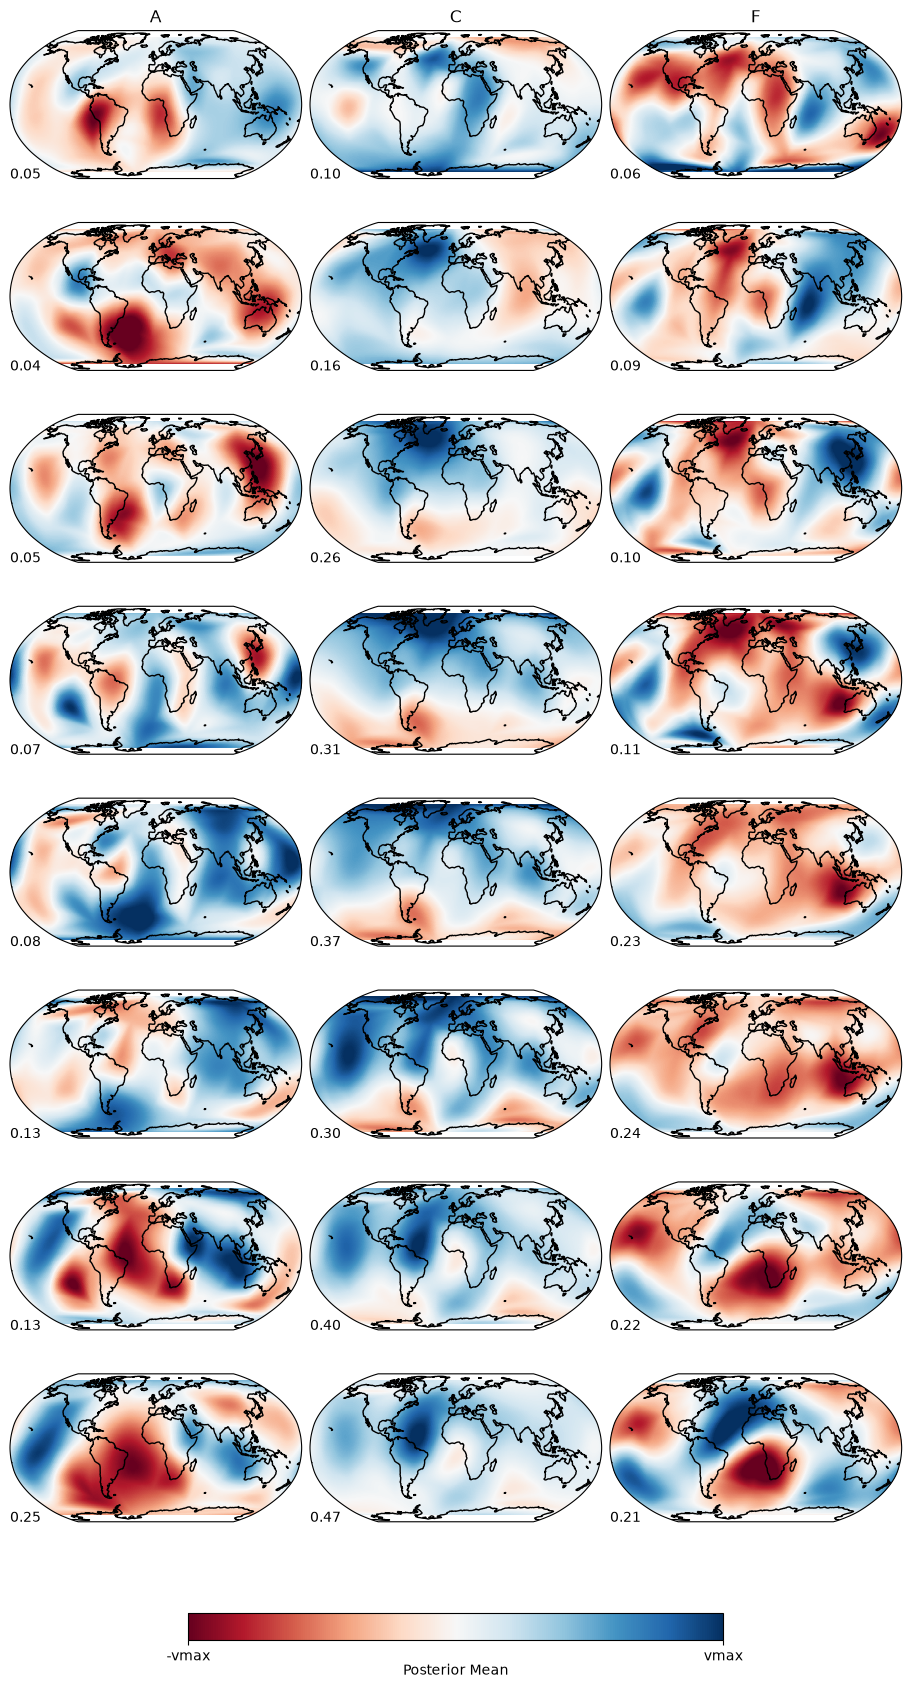

In [6]:
theta, phi = mesh.sampling.sampling_points().T
lat = 90.0 - np.degrees(theta)
lon = (np.degrees(phi) + 180.0) % 360.0 - 180.0


def interpolated(
    ax: plt.Axes,
    values: np.ndarray,
    cmap: str | None = None,
    norm: plt.Normalize | None = None,
) -> None:
    # Duplicate points shifted by +/-360 so the interpolation is periodic in longitude
    lon_ext = np.concatenate([lon - 360.0, lon, lon + 360.0])
    lat_ext = np.concatenate([lat, lat, lat])
    values_ext = np.concatenate([values, values, values])

    nlon, nlat = 720, 360
    grid_lon = np.linspace(-180.0, 180.0, nlon)
    grid_lat = np.linspace(-90.0, 90.0, nlat)
    Lon, Lat = np.meshgrid(grid_lon, grid_lat)

    grid = griddata(
        (lon_ext, lat_ext),
        values_ext,
        (Lon, Lat),
        method="cubic",
    )
    ax.pcolormesh(
        Lon,
        Lat,
        grid,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap,
        norm=norm,
    )


def scattered(
    ax: plt.Axes,
    values: np.ndarray,
    cmap: str | None = None,
    norm: plt.Normalize | None = None,
) -> None:
    ax.scatter(
        lon,
        lat,
        c=values,
        norm=norm,
        s=20,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )


def map_grid_figsize(nrows, ncols=3):
    width_per_col = 3.0
    height_per_row = 2.0
    top_bottom_margin = 0.8

    width = ncols * width_per_col
    height = nrows * height_per_row + top_bottom_margin
    return (width, height)


fig, axs = plt.subplots(
    mesh.n_radial,
    3,
    figsize=map_grid_figsize(mesh.n_radial, 3),
    layout="constrained",
    subplot_kw={"projection": ccrs.Robinson()},
    squeeze=False,
)
for ax, title in zip(axs[0], "ACF"):
    ax.set_title(title)

SCATTER = False
cmap = "RdBu"
for ax_row, A_rad, C_rad, F_rad in zip(
    axs[::-1], A, C, F
):  # flipping to get deepest at the bottom
    for ax, param in zip(ax_row, [A_rad, C_rad, F_rad]):
        vmax = np.abs(param).max()
        norm = plt.Normalize(-vmax, vmax)
        if SCATTER:
            scattered(ax, param, cmap, norm)
        else:
            interpolated(ax, param, cmap, norm)
        ax.coastlines()
        ax.text(0, 0, f"{float(vmax):.2f}", transform=ax.transAxes)

sm = plt.cm.ScalarMappable(cmap="RdBu")
cbar = fig.colorbar(sm, ax=axs, orientation="horizontal", shrink=0.6)
cbar.set_label(label="Posterior Mean", labelpad=0.0)
cbar.ax.set_xticks([0, 1], ["-vmax", "vmax"])


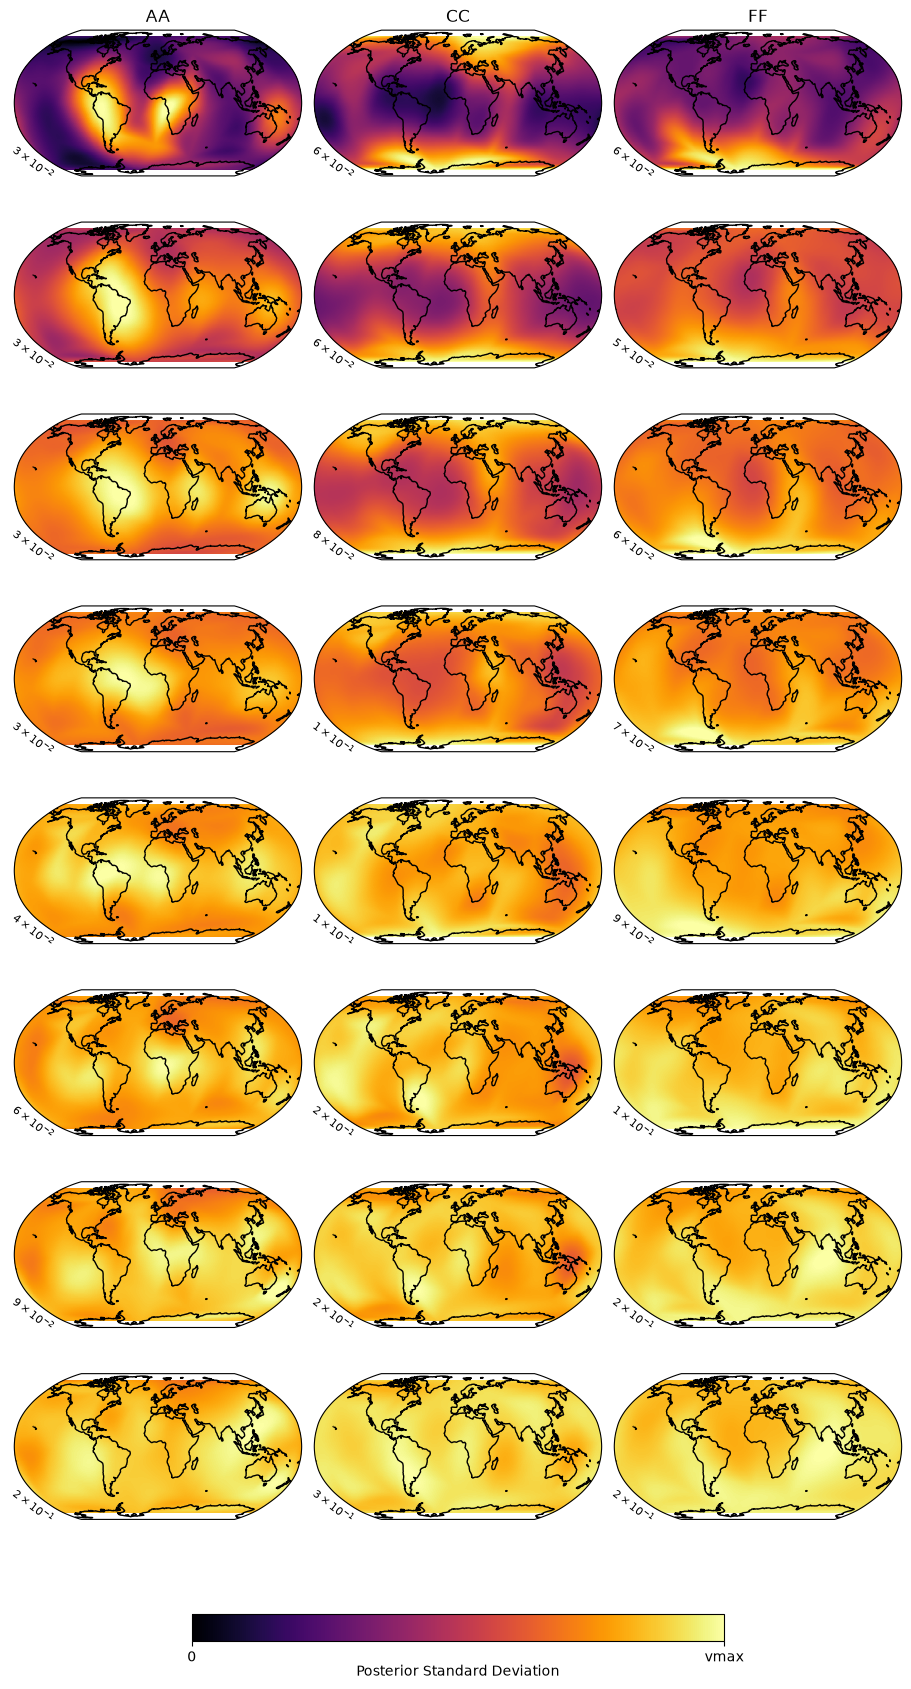

In [7]:
AA, AC, AF, CC, CF, FF = unpack_covariance(
    cov, mesh.n_radial, mesh.sampling.n_cells, reshape_blocks=False
)
sigma_A = np.sqrt(np.diag(AA).reshape(mesh.n_radial, mesh.sampling.n_cells))
sigma_C = np.sqrt(np.diag(CC).reshape(mesh.n_radial, mesh.sampling.n_cells))
sigma_F = np.sqrt(np.diag(FF).reshape(mesh.n_radial, mesh.sampling.n_cells))

fig, axs = plt.subplots(
    mesh.n_radial,
    3,
    figsize=map_grid_figsize(mesh.n_radial, 3),
    layout="constrained",
    subplot_kw={"projection": ccrs.Robinson()},
    squeeze=False,
)
for ax, title in zip(axs[0], ["AA", "CC", "FF"]):
    ax.set_title(title)

def format_maths(x, sig=2):
    if x == 0:
        return "$0$"
    s = f"{x:.{sig}e}"
    m, e = s.split("e")
    return rf"${m}\times10^{{{int(e)}}}$"

cmap = "inferno"
for ax_row, sA_rad, sC_rad, sF_rad in zip(axs[::-1], sigma_A, sigma_C, sigma_F):
    for ax, values in zip(ax_row, [sA_rad, sC_rad, sF_rad]):
        vmax = values.max()
        norm = plt.Normalize(0, vmax)
        if SCATTER:
            scattered(ax, values, norm=norm)
        else:
            interpolated(ax, values, cmap=cmap, norm=norm)
        ax.coastlines()
        ax.text(
            0.05,
            0.05,
            format_maths(vmax, sig=0),
            fontsize=8,
            ha="center",
            va="bottom",
            rotation_mode="anchor",
            rotation=-37.5,
            transform=ax.transAxes,
        )

sm = plt.cm.ScalarMappable(cmap=cmap)
cbar = fig.colorbar(sm, ax=axs, orientation="horizontal", shrink=0.6)
cbar.set_label(label="Posterior Standard Deviation", labelpad=0.0)
cbar.ax.set_xticks([0, 1], ["0", "vmax"])

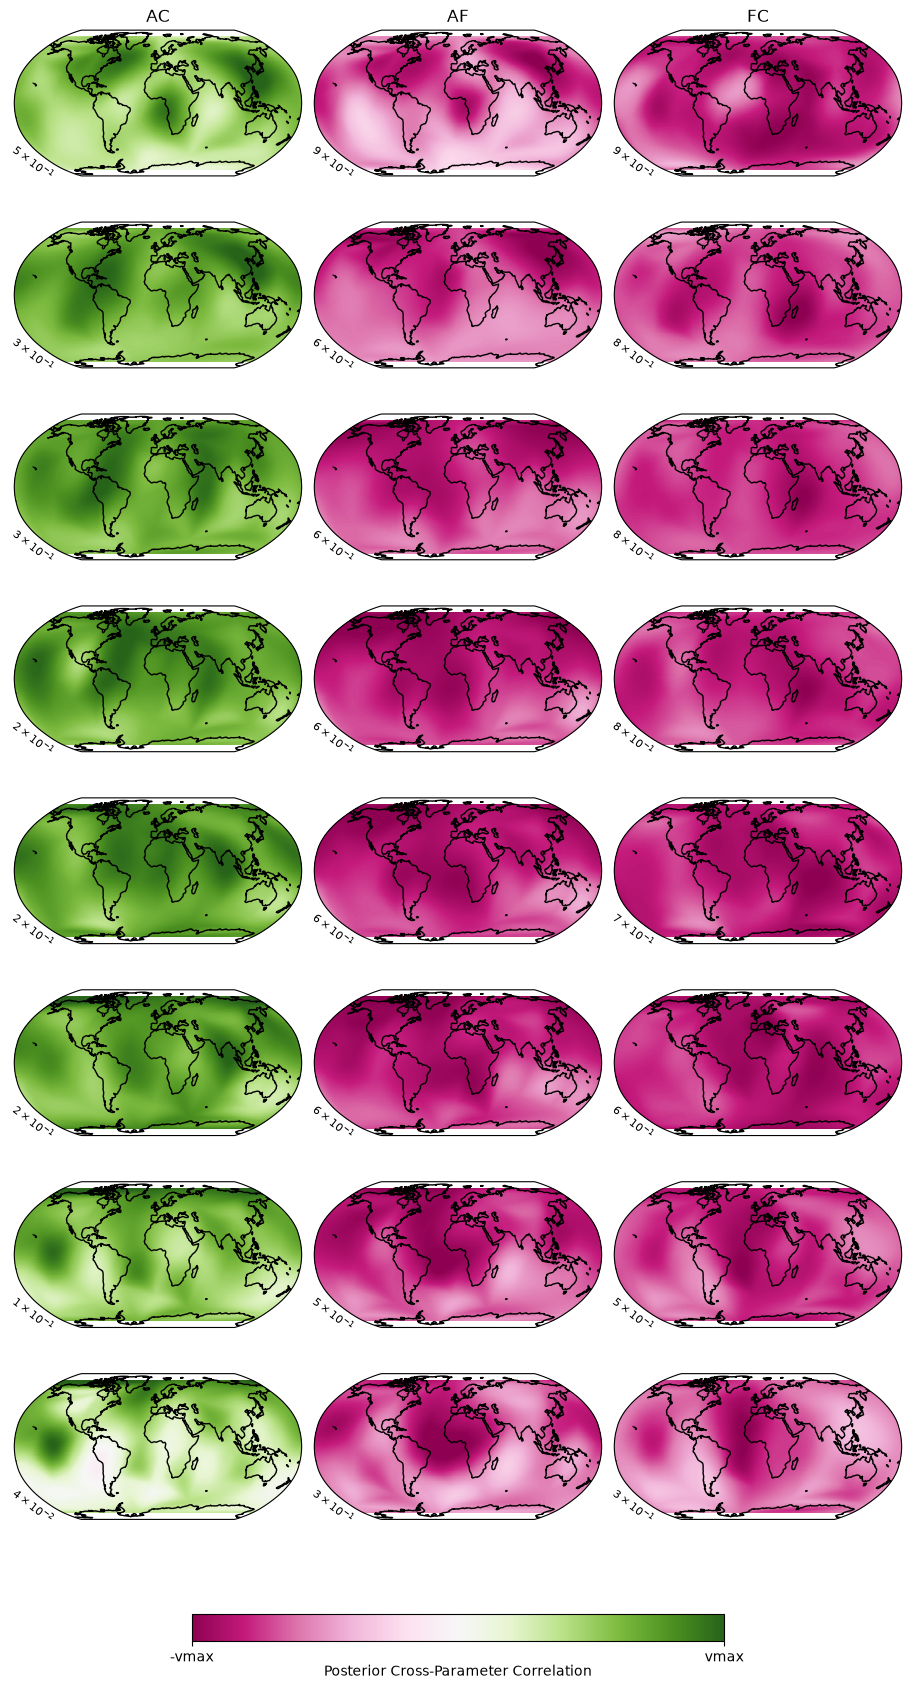

In [8]:
AA, AC, AF, CC, CF, FF = unpack_covariance(
    cov, mesh.n_radial, mesh.sampling.n_cells, reshape_blocks=False
)
sigma_A = np.sqrt(np.diag(AA))
sigma_C = np.sqrt(np.diag(CC))
sigma_F = np.sqrt(np.diag(FF))

corr_AC = (np.diag(AC) / (sigma_A * sigma_C)).reshape(mesh.n_radial, mesh.sampling.n_cells)
corr_AF = (np.diag(AF) / (sigma_A * sigma_F)).reshape(mesh.n_radial, mesh.sampling.n_cells)
corr_CF = (np.diag(CF) / (sigma_C * sigma_F)).reshape(mesh.n_radial, mesh.sampling.n_cells)

fig, axs = plt.subplots(
    mesh.n_radial,
    3,
    figsize=map_grid_figsize(mesh.n_radial, 3),
    layout="constrained",
    subplot_kw={"projection": ccrs.Robinson()},
    squeeze=False,
)
for ax, title in zip(axs[0], ["AC", "AF", "FC"]):
    ax.set_title(title)

def format_maths(x, sig=2):
    if x == 0:
        return "$0$"
    s = f"{x:.{sig}e}"
    m, e = s.split("e")
    return rf"${m}\times10^{{{int(e)}}}$"

cmap = "PiYG"
for ax_row, rhoAC, rhoAF, rhoCF in zip(axs[::-1], corr_AC, corr_AF, corr_CF):
    for ax, values in zip(ax_row, [rhoAC, rhoAF, rhoCF]):
        vmax = np.abs(values).max()
        norm = plt.Normalize(-vmax, vmax)
        if SCATTER:
            scattered(ax, values, norm=norm)
        else:
            interpolated(ax, values, cmap=cmap, norm=norm)
        ax.coastlines()
        ax.text(
            0.05,
            0.05,
            format_maths(vmax, sig=0),
            fontsize=8,
            ha="center",
            va="bottom",
            rotation_mode="anchor",
            rotation=-37.5,
            transform=ax.transAxes,
        )

sm = plt.cm.ScalarMappable(cmap=cmap)
cbar = fig.colorbar(sm, ax=axs, orientation="horizontal", shrink=0.6)
cbar.set_label(label="Posterior Cross-Parameter Correlation", labelpad=0.0)
cbar.ax.set_xticks([0, 1], ["-vmax", "vmax"])

<Axes: title={'center': 'Joint parameter correlation (A_r,C_r,F_r across shells)'}>

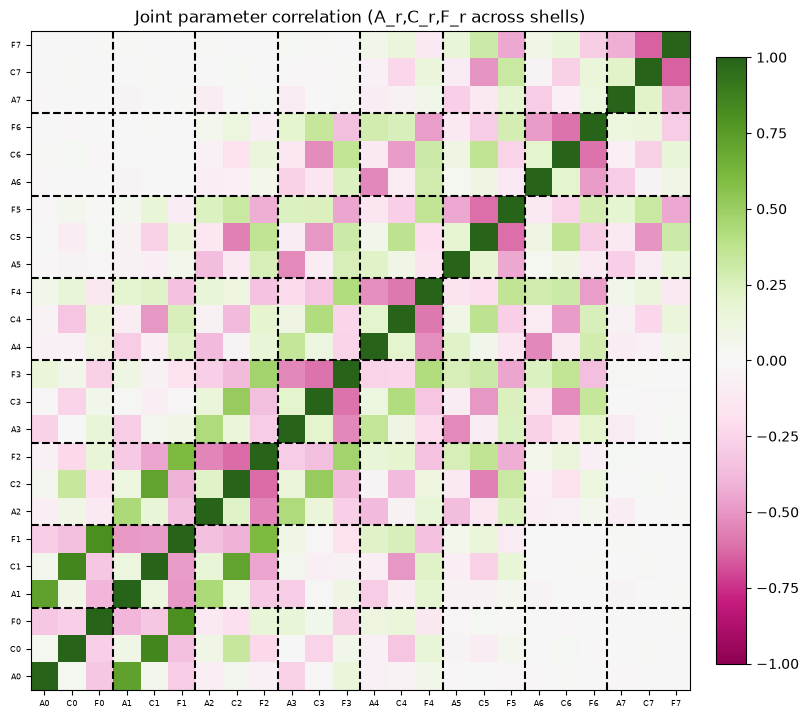

In [9]:
def shell_joint_mean_cov(mean: np.ndarray, cov: np.ndarray, mesh: SphericalMesh):
    """Return joint shell-averaged mean and covariance for all shells.

    Ordering returned: for shell r=0..R-1 the triplet is [A_r, C_r, F_r]"""
    n_radial = mesh.n_radial
    n_lateral = mesh.sampling.n_cells
    n_params = 3 * mesh.n_cells
    rows = []
    for r in range(n_radial):
        cells = r * n_lateral + np.arange(n_lateral)
        iA = 3 * cells
        iC = iA + 1
        iF = iA + 2

        rowA = np.zeros(n_params, dtype=float)
        rowC = np.zeros(n_params, dtype=float)
        rowF = np.zeros(n_params, dtype=float)

        rowA[iA] = 1.0 / n_lateral
        rowC[iC] = 1.0 / n_lateral
        rowF[iF] = 1.0 / n_lateral

        rows.append(rowA)
        rows.append(rowC)
        rows.append(rowF)

    L_all = np.vstack(rows)
    m_all = L_all @ mean  # shape (3,)
    C_all = L_all @ cov @ L_all.T  # shape (3,3)
    return m_all, C_all


def joint_labels(n_radial) -> list[str]:
    """Return list like ['A0','C0','F0','A1','C1','F1',...] for ticks/labels."""
    labs = []
    for r in range(n_radial):
        labs += [f"A{r}", f"C{r}", f"F{r}"]
    return labs


def plot_joint_correlation_heatmap(ax: plt.Axes, C_all: np.ndarray, n_radial: int):
    sd = np.sqrt(np.diag(C_all))
    corr = C_all / (sd[:, None] * sd[None, :])
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="PiYG", origin="lower")
    labs = joint_labels(n_radial)
    ax.set_xticks(np.arange(len(labs)))
    ax.set_yticks(np.arange(len(labs)))
    ax.set_xticklabels(labs, fontsize=6)
    ax.set_yticklabels(labs, fontsize=6)
    ax.set_title("Joint parameter correlation (A_r,C_r,F_r across shells)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for l in np.arange(2.5, 3 * (n_radial - 1) + 0.5, 3):
        ax.axhline(l, ls="--", c="k")
        ax.axvline(l, ls="--", c="k")
    return ax

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
m_all, C_all = shell_joint_mean_cov(mean, cov, mesh)
plot_joint_correlation_heatmap(ax, C_all, mesh.n_radial)

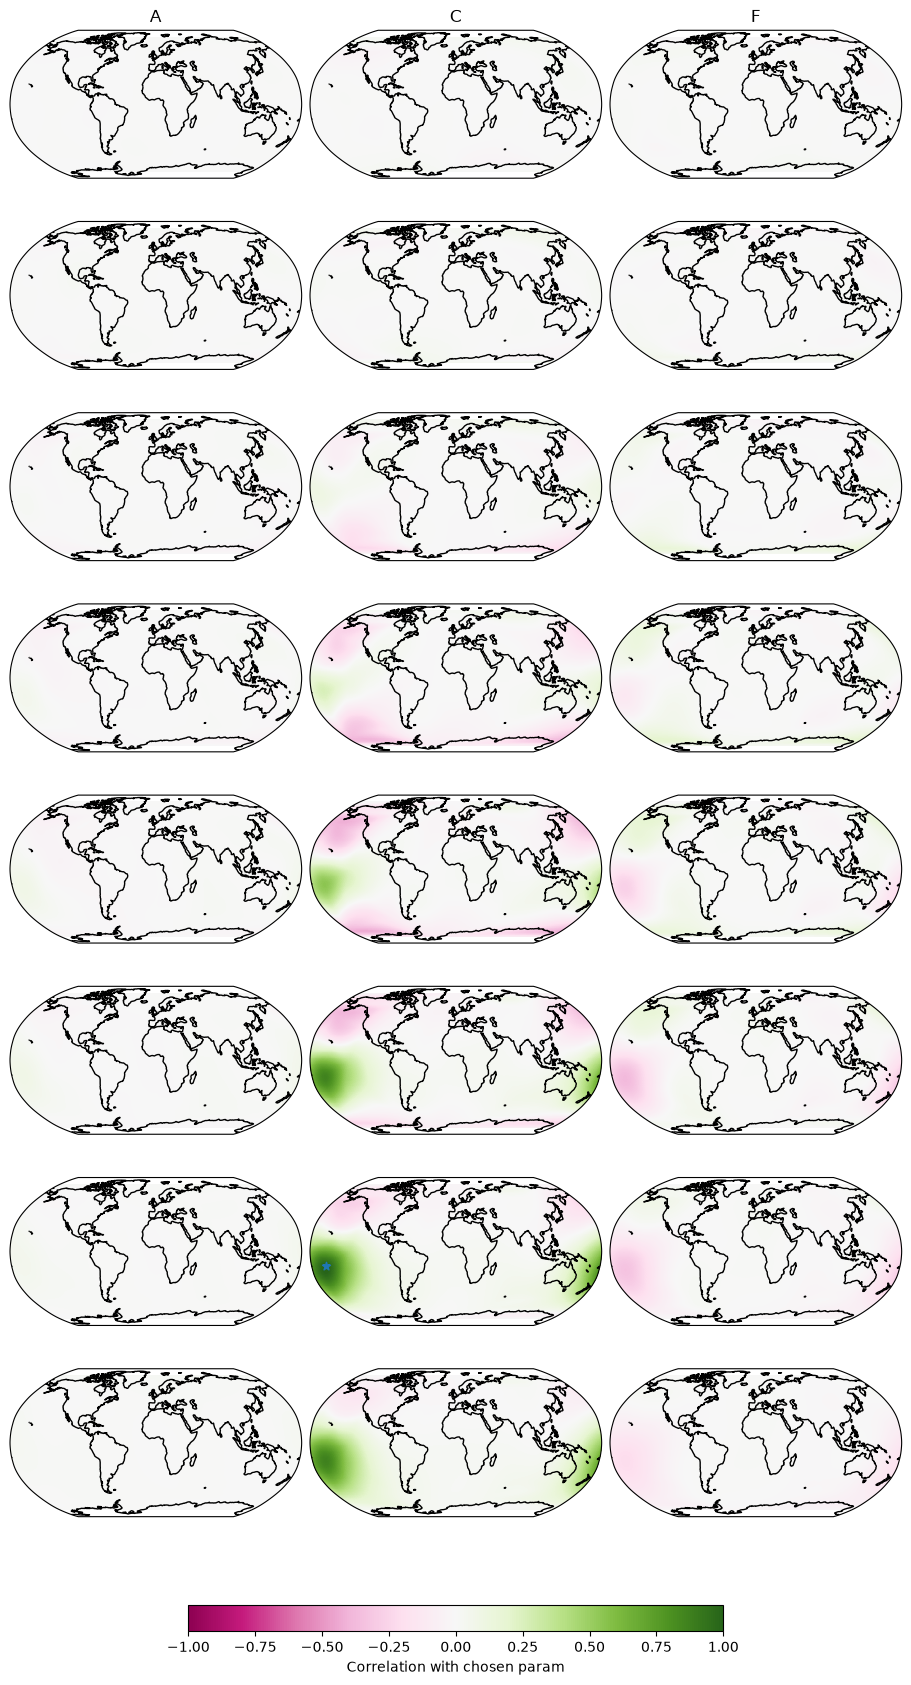

In [10]:
def param_global_index(param_type: str, r: int, l: int, mesh):
    offs = {"A": 0, "C": 1, "F": 2}[param_type]
    return 3 * (r * mesh.sampling.n_cells + l) + offs


def correlations_for_param(cov: np.ndarray, idx: int) -> np.ndarray:
    sd = np.sqrt(np.diag(cov))
    return cov[idx, :] / (sd[idx] * sd)


def plot_param_correlations_at_point(
    param_type: str,
    r: int,
    l: int,
    cov: np.ndarray,
    mesh: SphericalMesh,
):
    n_radial = mesh.n_radial
    n_lateral = mesh.sampling.n_cells
    point_rad = mesh.sampling.sampling_points()[l]
    p_lat = np.degrees(np.pi / 2 - point_rad[0])
    p_lon = np.degrees(point_rad[1])

    idx = param_global_index(param_type, r, l, mesh)
    corr = correlations_for_param(cov, idx)

    fig, axs = plt.subplots(
        n_radial,
        3,
        figsize=map_grid_figsize(n_radial, 3),
        layout="constrained",
        subplot_kw={"projection": ccrs.Robinson()},
        squeeze=False,
    )
    for ax, title in zip(axs[0], ["A", "C", "F"]):
        ax.set_title(title)

    norm = plt.Normalize(-1, 1)
    cmap = "PiYG"
    for shell_i in range(n_radial):
        cells = shell_i * n_lateral + np.arange(n_lateral)
        for col, ptype in enumerate(["A", "C", "F"]):
            offs = {"A": 0, "C": 1, "F": 2}[ptype]
            jidx = 3 * cells + offs
            vals = corr[jidx].reshape(n_lateral)

            ax = axs[
                n_radial - 1 - shell_i, col
            ]  # deepest at bottom
            if SCATTER:
                scattered(ax, vals, cmap=cmap, norm=norm)
            else:
                interpolated(ax, vals, cmap=cmap, norm=norm)
            ax.coastlines()

            if shell_i == r and ptype == param_type:
                ax.scatter(p_lon, p_lat, marker="*", transform=ccrs.PlateCarree())

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(
        sm,
        ax=axs,
        orientation="horizontal",
        shrink=0.6,
        label="Correlation with chosen param",
        # extend="both"
    )

p = ("C", 1, 25)  # (param_type, radial_idx, lateral_idx)
plot_param_correlations_at_point(*p, cov, mesh)


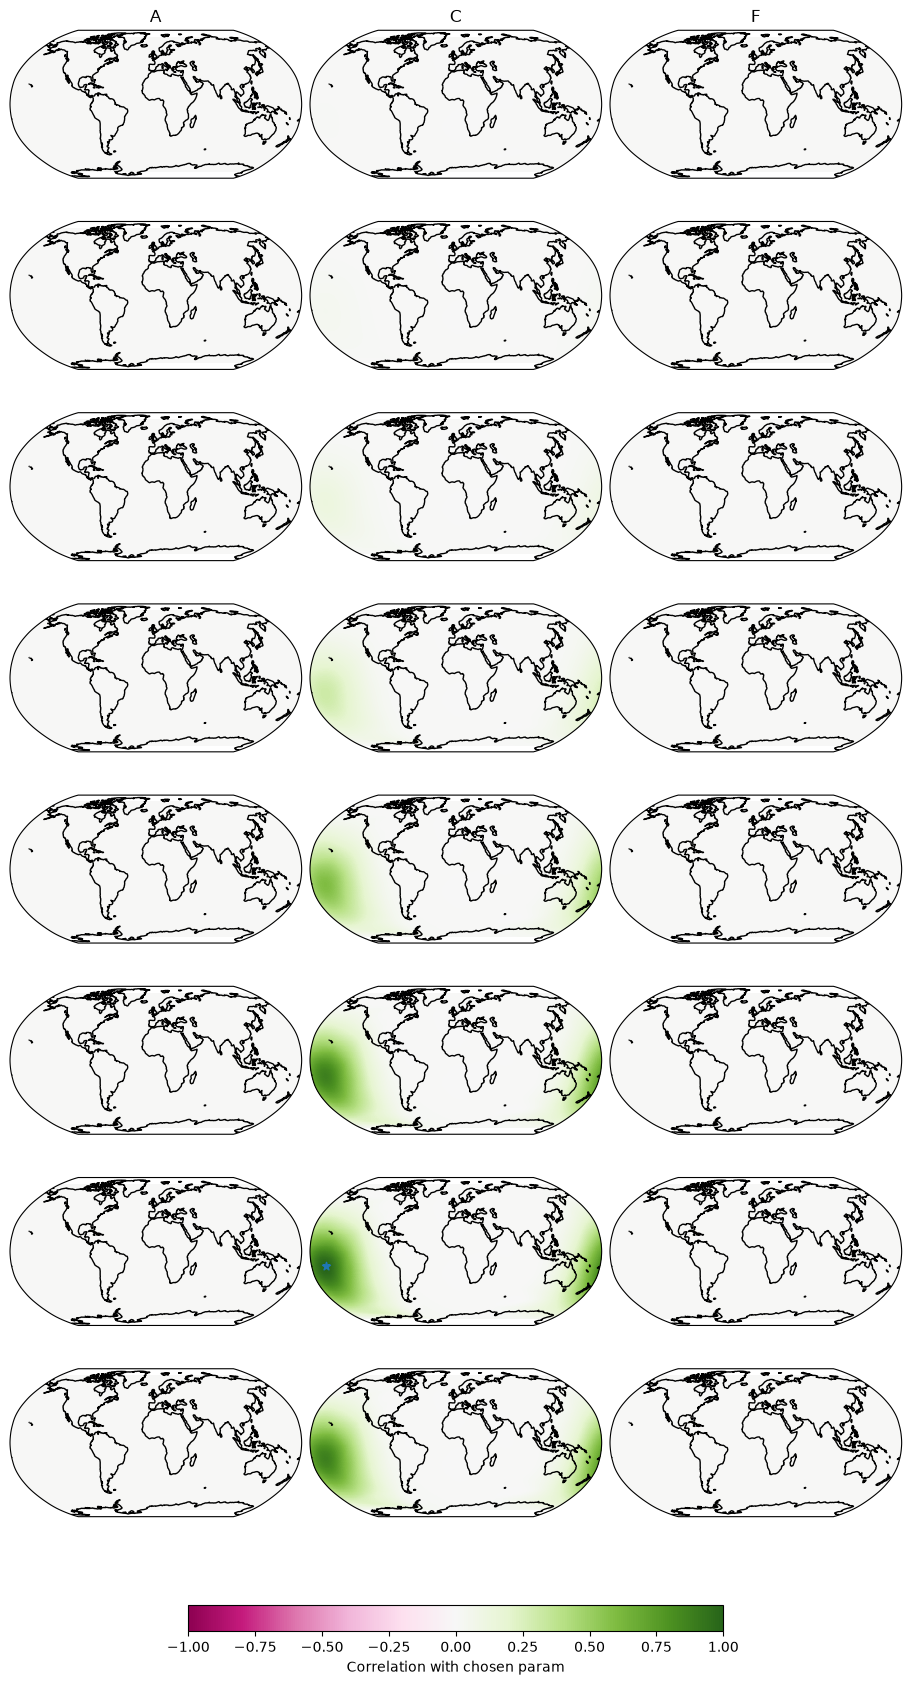

In [11]:
prior = ComponentSpec.from_dict(cfg.components.inferred[0]).to_gaussian_component(
    context
)
plot_param_correlations_at_point(*p, prior.C, mesh)

Text(0.5, 0, 'C')

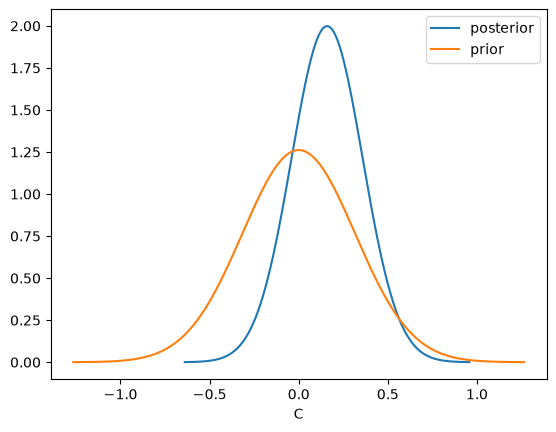

In [12]:
idx = param_global_index(*p, mesh=mesh)
post_mu = float(mean[idx])
post_sigma = float(np.sqrt(cov[idx, idx]))
prior_mu = float(prior.mu[idx])
prior_sigma = float(np.sqrt(prior.C[idx, idx]))

ax = plt.subplot()
for (mu, sigma), label in zip([(post_mu, post_sigma), (prior_mu, prior_sigma)], ["posterior", "prior"]):
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, pdf, label=label)
ax.legend()
ax.set_xlabel(p[0])

## Posterior predictive

$$d^* | d \sim \mathcal{N}(Gm_p, GC_pG^\top + C_d) $$

where $m_p$ and $C_p$ are the posterior mean and covariance.

In [13]:
inferred, nuisance = cfg.components.to_gaussian_components(context=context)

In [14]:
G = inferred[0].A
Cd = nuisance[0].C

ppd_mean = G @ mean
ppd_cov = G @ cov @ G.T + Cd

In [15]:
zeta = np.radians(df["zeta"])
tp_lon, tp_lat, tp_rad = np.stack(df["turning_point"].to_numpy()).T
residual = data - ppd_mean
ppd_sigma = np.sqrt(np.diag(ppd_cov))

zeta_bins = np.linspace(0, np.pi / 2, 9)
bin_centres = 0.5 * (zeta_bins[:-1] + zeta_bins[1:])
bin_idxs = np.digitize(zeta, zeta_bins)

binned_mean = np.array(
    [np.mean(residual[bin_idxs == i]) for i in range(1, len(zeta_bins))]
)
binned_sigma = np.array(
    [np.sqrt(np.mean(ppd_sigma[bin_idxs == i] ** 2)) for i in range(1, len(zeta_bins))]
)
pred_upper_2sigma = binned_mean + 2 * binned_sigma
pred_lower_2sigma = binned_mean - 2 * binned_sigma
pred_upper_3sigma = binned_mean + 3 * binned_sigma
pred_lower_3sigma = binned_mean - 3 * binned_sigma


Text(0, 0.5, 'Posterior predictive residual')

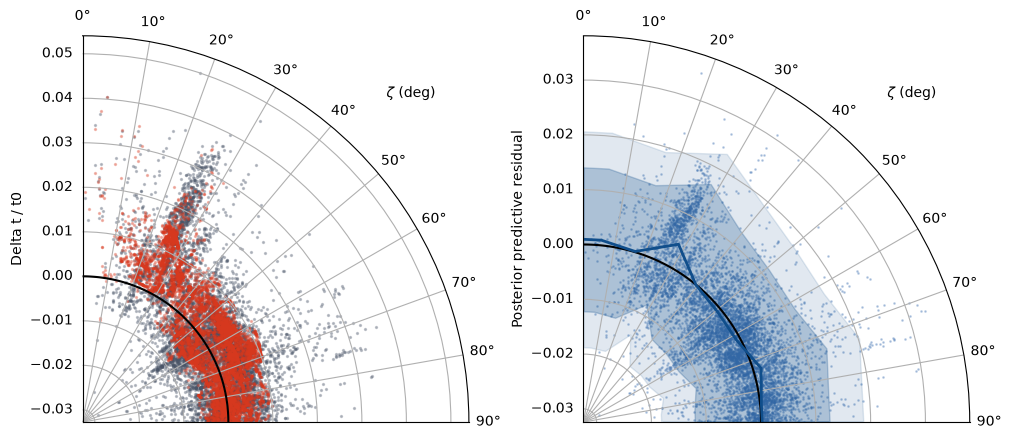

In [16]:
fig, axs = plt.subplots(
    1, 2, figsize=(10, 5), layout="constrained", subplot_kw={"projection": "polar"}
)
for ax in axs:
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.grid(True)
    ax.plot(np.linspace(0, np.pi / 2, 100), np.zeros(100), color="black")
    ax.text(
        0.85,
        0.85,
        "$\\zeta$ (deg)",
        transform=ax.transAxes,
        ha="center",
        va="center",
        rotation=0,
    )

ax = axs[0]
ax.scatter(zeta, data, s=2, c="#4A5568", alpha=0.3)
ax.scatter(zeta, ppd_mean, s=2, c="#D9381E", alpha=0.3)
ax.set_ylabel("Delta t / t0")


ax = axs[1]
ax.scatter(
    zeta,
    residual,
    s=1,
    c="#4575b4",
    alpha=0.3,
)

# padding to get shaded region to edges
bin_centres = np.concatenate([[0.0], bin_centres, [np.pi / 2]])
binned_mean = np.concatenate([[binned_mean[0]], binned_mean, [binned_mean[-1]]])
pred_lower_2sigma = np.concatenate(
    [[pred_lower_2sigma[0]], pred_lower_2sigma, [pred_lower_2sigma[-1]]]
)
pred_upper_2sigma = np.concatenate(
    [[pred_upper_2sigma[0]], pred_upper_2sigma, [pred_upper_2sigma[-1]]]
)
pred_lower_3sigma = np.concatenate(
    [[pred_lower_3sigma[0]], pred_lower_3sigma, [pred_lower_3sigma[-1]]]
)
pred_upper_3sigma = np.concatenate(
    [[pred_upper_3sigma[0]], pred_upper_3sigma, [pred_upper_3sigma[-1]]]
)
ax.plot(bin_centres, binned_mean, c="#104E8B", lw=2)
ax.fill_between(
    bin_centres, pred_lower_3sigma, pred_upper_3sigma, color="#104E8B", alpha=0.125
)
ax.fill_between(
    bin_centres, pred_lower_2sigma, pred_upper_2sigma, color="#104E8B", alpha=0.25
)
ax.set_ylabel("Posterior predictive residual")

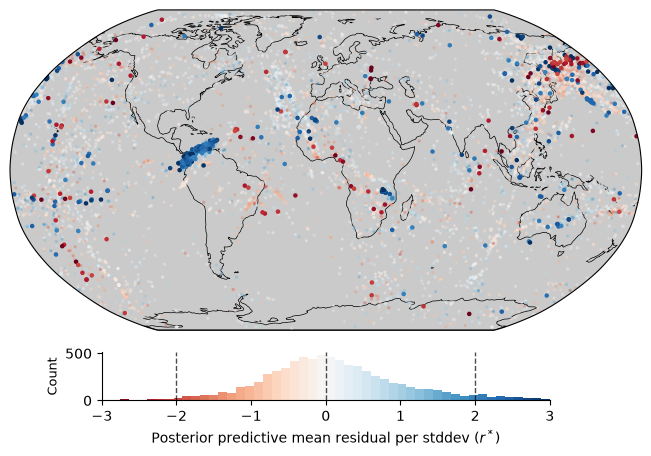

In [17]:
fig, ax = plt.subplots(
    1, 1, layout="constrained", subplot_kw={"projection": ccrs.Robinson()}
)

normalised_residual = residual / ppd_sigma
filt = np.abs(normalised_residual) > 2

vmax = np.max(np.abs(residual))
cmap = plt.cm.RdBu
norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

ax.add_feature(cfeature.LAND, facecolor="#CACACA", edgecolor="k")
ax.add_feature(cfeature.OCEAN, facecolor="#CACACA")
ax.scatter(
    tp_lon[~filt],
    tp_lat[~filt],
    s=2,
    c=normalised_residual[~filt],
    alpha=0.3,
    norm=norm,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
)
ax.scatter(
    tp_lon[filt],
    tp_lat[filt],
    s=5,
    c=normalised_residual[filt],
    norm=norm,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
)

ax_cbar = fig.add_axes([0.15, 0.02, 0.7, 0.10])
num_bins = 50
counts, bins, patches = ax_cbar.hist(
    normalised_residual, bins=num_bins, range=(-3, 3), edgecolor="black", linewidth=0.3
)
for bin_left, patch in zip(bins[:-1], patches):
    bin_center = bin_left + (bins[1] - bins[0]) / 2.0
    patch.set_facecolor(cmap(norm(bin_center)))
    patch.set_edgecolor(None)

ax_cbar.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax_cbar.axvline(-2, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax_cbar.axvline(2, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax_cbar.set_xlim(-3.0, 3.0)
ax_cbar.set_xlabel(
    r"Posterior predictive mean residual per stddev ($r^*$)", fontsize=10
)
ax_cbar.set_ylabel("Count", fontsize=9)
ax_cbar.spines["top"].set_visible(False)
ax_cbar.spines["right"].set_visible(False)

In [18]:
nrows, ncols = 3, 3

rng = np.random.default_rng(42)
posterior_predictive_draws = rng.multivariate_normal(ppd_mean, ppd_cov, nrows * ncols)
posterior_predictive_draws = data - posterior_predictive_draws
posterior_predictive_draws[nrows * ncols // 2] = residual  # mean residual in the middle

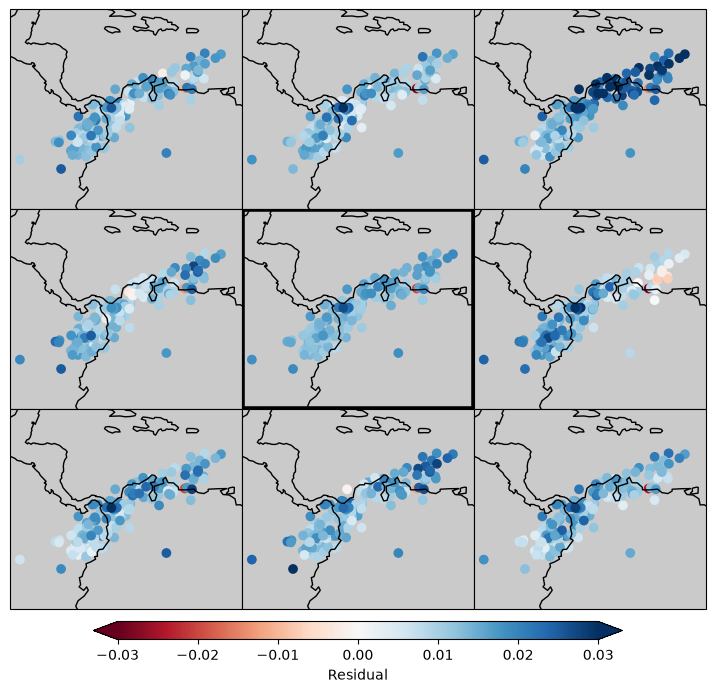

In [19]:
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=-65,
    central_latitude=8,
)
extent = [-90, -60, -5, 20]
tmp_fig, tmp_ax = plt.subplots(subplot_kw={"projection": proj})
tmp_ax.set_extent(extent, crs=ccrs.PlateCarree())
tmp_fig.canvas.draw()  # must draw to populate renderer
bbox = tmp_ax.get_window_extent()  # in display (pixel) coords
aspect = bbox.width / bbox.height
plt.close(tmp_fig)

per_cell_height_in = 2.0
per_cell_width_in = per_cell_height_in * aspect
fig_w = ncols * per_cell_width_in
fig_h = nrows * per_cell_height_in

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(
    nrows, ncols, left=0.0, right=1.0, top=1.0, bottom=0.0, wspace=0.0, hspace=0.0
)

cmap = "RdBu"
vmax = np.abs(posterior_predictive_draws).max()
vmax = 0.03
norm = plt.Normalize(-vmax, vmax)

sample_idx = 0
for i in range(nrows):
    for j in range(ncols):
        ax = fig.add_subplot(gs[i, j], projection=proj)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.coastlines(resolution="110m")
        ax.add_feature(cfeature.LAND, facecolor="#CACACA", edgecolor="k")
        ax.add_feature(cfeature.OCEAN, facecolor="#CACACA")

        ax.scatter(
            tp_lon[filt],
            tp_lat[filt],
            c=posterior_predictive_draws[sample_idx, filt],
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
        )
        ax.set_xticks([])
        ax.set_yticks([])

        if sample_idx == nrows * ncols // 2:
            rect = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                fill=False,
                linewidth=4.0,
                edgecolor="k",
                zorder=10,
            )
            ax.add_patch(rect)

        sample_idx += 1


sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = fig.add_axes([0.12, -0.05, 0.76, 0.03])
cb = fig.colorbar(sm, cax=cax, orientation="horizontal", extend="both")
cb.set_label("Residual")